In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [ ]:
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
print(df.shape)
print(df.columns)
print(df.info())

(9994, 21)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 


In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


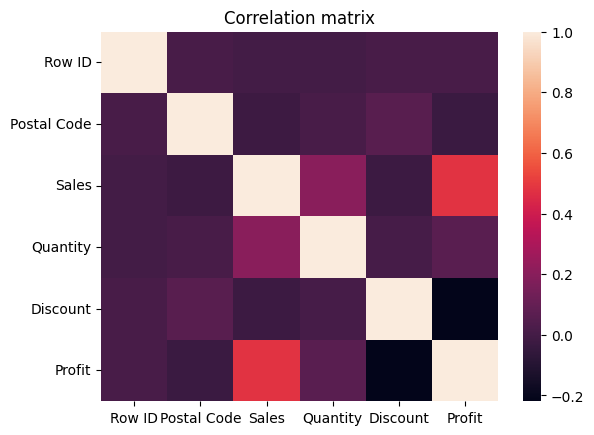

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=False)
plt.title("Correlation matrix")
plt.show()

In [ ]:
discount_analysis = df.groupby('Discount')[['Sales', 'Profit']].mean()
print(discount_analysis)

               Sales      Profit
Discount                        
0.00      226.742074   66.900292
0.10      578.397351   96.055074
0.15      529.971567   27.288298
0.20      209.076940   24.702572
0.30      454.742974  -45.679636
0.32      536.794770  -88.560656
0.40      565.134874 -111.927429
0.45      498.634000 -226.646464
0.50      892.705152 -310.703456
0.60       48.150000  -43.077212
0.70       97.177708  -95.874060
0.80       56.545853 -101.796797


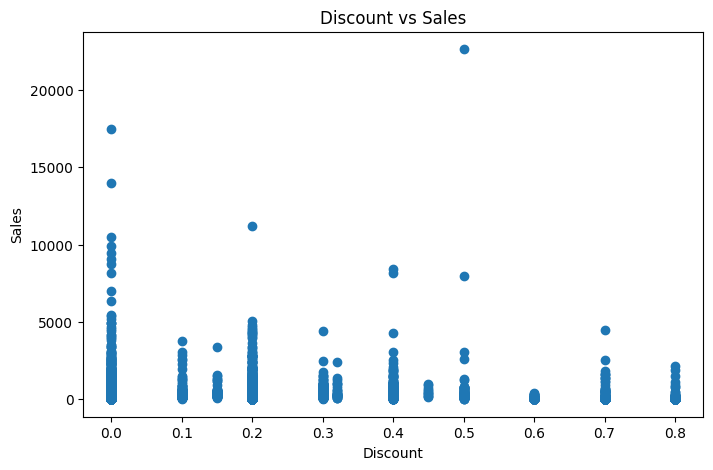

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['Discount'], df['Sales'])
plt.xlabel('Discount')
plt.ylabel('Sales')
plt.title('Discount vs Sales')
plt.show()

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['order_year'] = df['Order Date'].dt.year
df['order_month'] = df['Order Date'].dt.month
df['order_quarter'] = df['Order Date'].dt.quarter

In [ ]:
df = df.drop([
    'Row ID', 'Order ID', 'Customer ID', 'Customer Name',
    'Product ID', 'Product Name', 'City', 'State', 'Country',
    'Ship Date', 'Order Date', 'Postal Code', 'Profit'
], axis=1)

In [ ]:
df['discount_x_quantity'] = df['Discount'] * df['Quantity']  # взаимодействие
df['is_discounted']       = (df['Discount'] > 0).astype(int)

In [ ]:
# target
X = df.drop('Sales', axis=1)
y = df['Sales']

In [ ]:
y = np.log1p(df['Sales'])

In [ ]:
categorical_features = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']

numeric_features = [
    'Quantity', 'Discount', 'order_year', 'order_month',
    'order_quarter', 'discount_x_quantity', 'is_discounted'  # добавили новые
]

In [ ]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
pred_lr_log = lr_pipeline.predict(X_test)

In [ ]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)
pred_rf_log = rf_pipeline.predict(X_test)

In [ ]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)
pred_xgb_log = xgb_pipeline.predict(X_test)

In [ ]:
y_test_orig = np.expm1(y_test)

pred_lr  = np.expm1(pred_lr_log)
pred_rf  = np.expm1(pred_rf_log)
pred_xgb = np.expm1(pred_xgb_log)

In [ ]:
#сравнение моделей
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [
        mean_absolute_error(y_test, pred_lr_log),
        mean_absolute_error(y_test, pred_rf_log),
        mean_absolute_error(y_test, pred_xgb_log)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, pred_lr_log)),
        np.sqrt(mean_squared_error(y_test, pred_rf_log)),
        np.sqrt(mean_squared_error(y_test, pred_xgb_log))
    ],
    'R2': [
        r2_score(y_test, pred_lr_log),
        r2_score(y_test, pred_rf_log),
        r2_score(y_test, pred_xgb_log)
    ]
})

print(results)

               Model       MAE      RMSE        R2
0  Linear Regression  0.805421  1.028351  0.584829
1      Random Forest  0.855757  1.104322  0.521220
2            XGBoost  0.803329  1.027093  0.585843


In [ ]:
joblib.dump(xgb_pipeline, 'model.pkl')

['model.pkl']

In [ ]:
!pip install streamlit pyngrok

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

model = joblib.load('model.pkl')

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['order_year'] = df['Order Date'].dt.year
df['order_month'] = df['Order Date'].dt.month

st.title("Superstore Sales Prediction")

ship_mode = st.selectbox("Ship Mode", df['Ship Mode'].unique())
segment = st.selectbox("Segment", df['Segment'].unique())
region = st.selectbox("Region", df['Region'].unique())
category = st.selectbox("Category", df['Category'].unique())
sub_category = st.selectbox("Sub-Category", df['Sub-Category'].unique())

quantity = st.slider("Quantity", 1, 14, 1)
discount = st.slider("Discount", 0.0, 1.0, 0.0)

year = st.selectbox("Year", sorted(df['order_year'].unique()))
month = st.slider("Month", 1, 12, 1)

if st.button("Predict Sales"):
    input_df = pd.DataFrame([{
        'Ship Mode': ship_mode,
        'Segment': segment,
        'Region': region,
        'Category': category,
        'Sub-Category': sub_category,
        'Quantity': quantity,
        'Discount': discount,
        'order_year': year,
        'order_month': month
    }])

    pred = model.predict(input_df)
    st.success(f"Predicted Sales: ${pred[0]:.2f}")

st.subheader("Sales Distribution")
fig, ax = plt.subplots()
ax.hist(df['Sales'], bins=30)
st.pyplot(fig)

st.subheader("Sales by Category")
fig, ax = plt.subplots()
sns.barplot(data=df, x='Category', y='Sales', ax=ax)
st.pyplot(fig)

st.subheader("Sales by Region")
fig, ax = plt.subplots()
sns.barplot(data=df, x='Region', y='Sales', ax=ax)
st.pyplot(fig)

Writing app.py


In [ ]:
%%writefile requirements.txt
streamlit==1.57.0
pandas==2.2.2
scikit-learn==1.6.1
xgboost==3.2.0
joblib==1.5.3
matplotlib==3.10.0
seaborn==0.13.2
numpy==1.26.4

Writing requirements.txt


In [ ]:
import streamlit
import pandas
import sklearn
import xgboost
import joblib
import matplotlib
import seaborn

print("matplotlib:", matplotlib.__version__)
print("streamlit:", streamlit.__version__)
print("pandas:", pandas.__version__)
print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("joblib:", joblib.__version__)

matplotlib: 3.10.0
streamlit: 1.57.0
pandas: 2.2.2
sklearn: 1.6.1
xgboost: 3.2.0
joblib: 1.5.3
